<a href="https://colab.research.google.com/github/Diego-Rodriguez16/mini-robots-2026-II/blob/main/5_Redes_Neuronales/Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Redes Neuronales: ejercicios del capítulo 5

**Idea general:** una red neuronal es una función con muchos "botones" (los pesos). Se le muestran ejemplos, ve cuánto se equivoca (la pérdida) y ajusta los botones para equivocarse menos (backpropagation). Se repite muchas veces (épocas).

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.model_selection import train_test_split

## Ejercicio 1. Red con dos capas ocultas para predecir

**Qué vamos a hacer:** tomar una tabla de un experimento y enseñarle a una red a predecir.

**Experimento:** péndulo. Se mide cuánto tarda en oscilar (periodo) según el largo de la cuerda. Los datos los simulé con la fórmula del péndulo más un poquito de error, como si se hubieran medido.

In [21]:
L = np.linspace(0.2, 2.0, 40)                                   # largo de la cuerda (m)
T = 2*np.pi*np.sqrt(L/9.8) + np.random.normal(0, 0.02, 40)      # periodo (s) con algo de error

tabla = pd.DataFrame({"Largo (m)": L, "Periodo (s)": T})
tabla.head()

,Largo (m),Periodo (s)
0,0.200000,0.866062
1,0.246154,1.012021
2,0.292308,1.069014
3,0.338462,1.189263
4,0.384615,1.264923


**Paso 1.** Separar datos: 80% para entrenar y 20% para probar con datos que la red no vio.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(L, T, test_size=0.2)

**Paso 2.** Crear la red: 1 entrada (largo), **2 capas ocultas** de 16 neuronas y 1 salida (el periodo).

In [23]:
modelo1 = keras.Sequential([
    keras.layers.Input(shape=(1,)),
    keras.layers.Dense(16, activation="relu"),   # capa oculta 1
    keras.layers.Dense(16, activation="relu"),   # capa oculta 2
    keras.layers.Dense(1)                        # salida
])
modelo1.compile(optimizer="adam", loss="mean_squared_error")

**Paso 3.** Entrenar (500 épocas) y ver cómo baja el error.

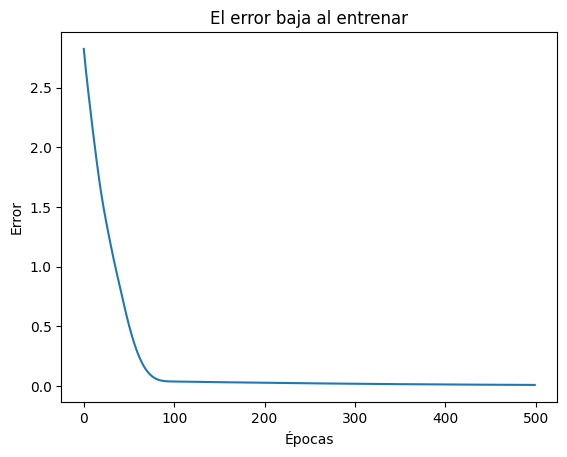

In [24]:
historia = modelo1.fit(X_train, y_train, epochs=500, verbose=0)

plt.plot(historia.history["loss"])
plt.xlabel("Épocas"); plt.ylabel("Error"); plt.title("El error baja al entrenar")
plt.show()

**Paso 4.** Predecir con datos nuevos y comparar con la fórmula real.

In [25]:
nuevos = np.array([0.5, 1.0, 1.5])
prediccion = modelo1.predict(nuevos, verbose=0).flatten()
real = 2*np.pi*np.sqrt(nuevos/9.8)

pd.DataFrame({"Largo (m)": nuevos, "Predicción red (s)": prediccion, "Fórmula (s)": real})

,Largo (m),Predicción red (s),Fórmula (s)
0,0.5,1.346141,1.419227
1,1.0,1.903356,2.007090
2,1.5,2.459886,2.458173


**Conclusión 1:** el error baja al entrenar y las predicciones quedan muy cerca del valor real. La red aprendió la relación entre el largo y el periodo solo viendo ejemplos.

## Ejercicio 2. Clasificar prendas de vestir (Fashion MNIST)

**Qué vamos a hacer:** enseñarle a la red a decir qué prenda hay en una foto. El dataset tiene 70.000 imágenes de 28×28 píxeles y 10 tipos de prenda.

Imágenes de entrenamiento: (60000, 28, 28)


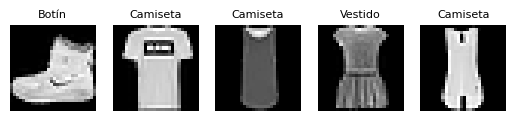

In [26]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
nombres = ["Camiseta", "Pantalón", "Suéter", "Vestido", "Abrigo",
           "Sandalia", "Camisa", "Tenis", "Bolso", "Botín"]

print("Imágenes de entrenamiento:", x_train.shape)

for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(nombres[y_train[i]], fontsize=8)
    plt.axis("off")
plt.show()

Cada píxel va de 0 a 255. Lo dividimos entre 255 para que quede entre 0 y 1 (así la red aprende mejor).

In [27]:
x_train = x_train / 255
x_test = x_test / 255

**Crear la red con dos capas ocultas:**
- `Flatten`: convierte la imagen 28×28 en una fila de 784 números.
- `Dense(128)` y `Dense(64)`: las dos capas ocultas.
- `Dense(10, softmax)`: salida con 10 neuronas, una por prenda; da una probabilidad para cada una.

In [28]:
modelo2 = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

modelo2.compile(optimizer="adam",
                loss="sparse_categorical_crossentropy",
                metrics=["accuracy"])

historia2 = modelo2.fit(x_train, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8238 - loss: 0.5021 - val_accuracy: 0.8390 - val_loss: 0.4371
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8624 - loss: 0.3753 - val_accuracy: 0.8642 - val_loss: 0.3666
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8773 - loss: 0.3364 - val_accuracy: 0.8675 - val_loss: 0.3681
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8862 - loss: 0.3127 - val_accuracy: 0.8797 - val_loss: 0.3489
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8893 - loss: 0.2939 - val_accuracy: 0.8742 - val_loss: 0.3549
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8945 - loss: 0.2819 - val_accuracy: 0.8792 - val_loss: 0.3341
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9003 - loss: 0.2687 - val_accuracy: 0.8793 - val_loss: 0.3363
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9033 - loss: 0.2574 

**Probar el modelo** con las 10.000 imágenes de prueba:

Precisión en prueba: 87.4 %


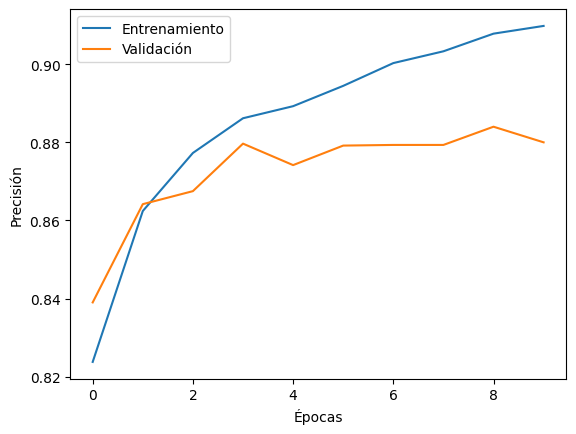

In [29]:
perdida, precision = modelo2.evaluate(x_test, y_test, verbose=0)
print("Precisión en prueba:", round(precision*100, 1), "%")

plt.plot(historia2.history["accuracy"], label="Entrenamiento")
plt.plot(historia2.history["val_accuracy"], label="Validación")
plt.xlabel("Épocas"); plt.ylabel("Precisión"); plt.legend()
plt.show()

**Conclusión 2:** la precisión fue de 87.4%. La curva de entrenamiento sigue subiendo pero la de validación se aplana: la red empieza a memorizar (*overfitting*, figura 5.12 del documento).

## Ejercicio 3. Explicación de las funciones (Fashion MNIST)

Con el mismo modelo del ejercicio 2, esto hace cada instrucción:

| Instrucción | ¿Qué hace? |
|---|---|
| `load_data()` | Descarga las imágenes y sus rótulos, ya separados en entrenamiento y prueba. |
| `x / 255` | Deja los píxeles entre 0 y 1. |
| `Sequential` | Crea una red donde las capas van una después de otra. |
| `Flatten` | Convierte la imagen 28×28 en un vector de 784 números. |
| `Dense(128, relu)` | Capa de 128 neuronas conectadas con todas las anteriores. ReLU deja pasar los positivos y pone 0 a los negativos. |
| `Dense(10, softmax)` | Capa de salida. Softmax convierte los resultados en probabilidades que suman 1. |
| `compile` | Define cómo aprende: `adam` (el método que ajusta los pesos), la función de pérdida y la métrica. |
| `fit` | Entrena: propaga, calcula el error, y hace backpropagation, por cada época. |
| `evaluate` | Mide qué tan bien funciona con datos nuevos. |
| `predict` | Da las 10 probabilidades para una imagen. |

**Veamos predicciones reales:** en verde acierta, en rojo se equivoca.

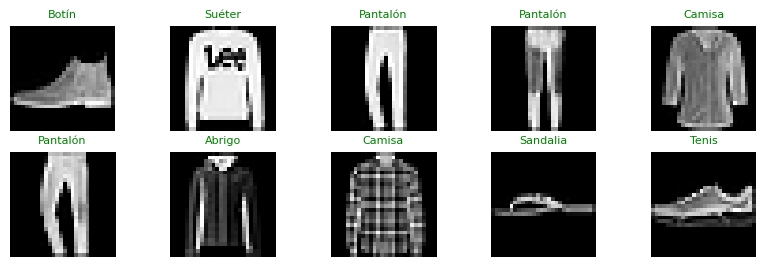

In [30]:
probabilidades = modelo2.predict(x_test[:10], verbose=0)
prediccion = np.argmax(probabilidades, axis=1)      # la prenda con mayor probabilidad

plt.figure(figsize=(10, 3))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i], cmap="gray")
    color = "green" if prediccion[i] == y_test[i] else "red"
    plt.title(nombres[prediccion[i]], color=color, fontsize=8)
    plt.axis("off")
plt.show()

**Conclusión 3:** la red acierta todas en este caso


## Ejercicio 4. Dataset de Kaggle

**Dataset:** Iris (flores). Se mide cada flor y hay que decir de qué especie es.
- **Características (features):** largo y ancho del sépalo, largo y ancho del pétalo (4 números).
- **Rótulo:** la especie (setosa, versicolor o virginica).

In [31]:
!pip -q install kagglehub

In [32]:
import kagglehub, os

ruta = kagglehub.dataset_download("uciml/iris")
datos = pd.read_csv(os.path.join(ruta, "Iris.csv")).drop(columns="Id")
datos.head()

Using Colab cache for faster access to the 'iris' dataset.


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


Se separan las características (X) del rótulo (y), se convierte el nombre de la especie a número (0, 1, 2) y se estandarizan las medidas.

In [33]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

X = datos.drop(columns="Species").values
codificador = LabelEncoder()
y = codificador.fit_transform(datos["Species"])
print("Clases:", list(codificador.classes_))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

escala = StandardScaler().fit(X_train)
X_train = escala.transform(X_train)
X_test = escala.transform(X_test)

Clases: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


Modelo: 4 entradas, dos capas ocultas de 16 y 3 salidas (una por especie).

In [34]:
modelo4 = keras.Sequential([
    keras.layers.Input(shape=(4,)),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(3, activation="softmax")
])
modelo4.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
modelo4.fit(X_train, y_train, epochs=100, verbose=0)

precision4 = modelo4.evaluate(X_test, y_test, verbose=0)[1]
print("Precisión en prueba:", round(precision4*100, 1), "%")

Precisión en prueba: 96.7 %


**Ejemplos de internet:** medidas típicas de flores que aparecen en la descripción del dataset (UCI / Wikipedia) con su especie.

In [35]:
ejemplos = np.array([[5.1, 3.5, 1.4, 0.2],    # setosa
                     [5.9, 3.0, 4.2, 1.5],    # versicolor
                     [6.3, 3.3, 6.0, 2.5]])   # virginica
reales = ["Iris-setosa", "Iris-versicolor", "Iris-virginica"]

p = modelo4.predict(escala.transform(ejemplos), verbose=0)
pd.DataFrame({"Real": reales,
              "Predicción": codificador.inverse_transform(p.argmax(axis=1))})

,Real,Predicción
0,Iris-setosa,Iris-setosa
1,Iris-versicolor,Iris-versicolor
2,Iris-virginica,Iris-virginica


**Conclusión 4:** la red clasificó bien las flores (precisión 96.7%). Con solo 4 medidas alcanza para reconocer la especie. Como el conjunto de prueba es pequeño (30 flores), el resultado cambia un poco cada vez que se ejecuta.

## Ejercicio 5. Punto libre: red convolucional (CNN)

**Idea:** en el ejercicio 2 la red trataba cada píxel por separado. Una **convolución** usa un filtro pequeño que se desliza por la imagen para detectar cosas como bordes. El **max pooling** encoge la imagen quedándose con el valor más grande de cada bloque.

**Ejemplo a mano del documento:** imagen 6×6 con el filtro de bordes.

In [36]:
imagen = np.array([[3,0,1,2,7,4],
                   [1,5,8,9,3,1],
                   [2,7,2,5,1,3],
                   [0,1,3,1,7,8],
                   [4,2,1,6,2,8],
                   [2,4,5,2,3,9]])
filtro = np.array([[1,0,-1],
                   [1,0,-1],
                   [1,0,-1]])

resultado = np.zeros((4, 4))
for i in range(4):
    for j in range(4):
        pedazo = imagen[i:i+3, j:j+3]              # se toma un bloque 3x3
        resultado[i, j] = np.sum(pedazo * filtro)  # se multiplica por el filtro y se suma
print(resultado)

[[ -5.  -4.   0.   8.]
 [-10.  -2.   2.   3.]
 [  0.  -2.  -4.  -7.]
 [ -3.  -2.  -3. -16.]]


El primer valor es -5, igual que en el documento. Una imagen 6×6 con filtro 3×3 da una 4×4.

**Ahora una CNN en Fashion MNIST** para comparar con el ejercicio 2:

In [37]:
# se recargan las imágenes porque en el ejercicio 4 se reutilizaron los nombres X_train, y_train
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
x_train = x_train.reshape(-1, 28, 28, 1) / 255
x_test = x_test.reshape(-1, 28, 28, 1) / 255

cnn = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    keras.layers.Conv2D(32, (3, 3), activation="relu"),   # filtros que detectan bordes
    keras.layers.MaxPooling2D((2, 2)),                    # encoge la imagen
    keras.layers.Conv2D(64, (3, 3), activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])
cnn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cnn.fit(x_train, y_train, epochs=5, validation_split=0.1)

precision_cnn = cnn.evaluate(x_test, y_test, verbose=0)[1]
print("Precisión CNN:", round(precision_cnn*100, 1), "%")
print("Precisión red del ejercicio 2:", round(precision*100, 1), "%")

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 65s 35ms/step - accuracy: 0.8261 - loss: 0.4805 - val_accuracy: 0.8727 - val_loss: 0.3439
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 49s 29ms/step - accuracy: 0.8831 - loss: 0.3236 - val_accuracy: 0.8925 - val_loss: 0.3019
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 81s 29ms/step - accuracy: 0.8985 - loss: 0.2751 - val_accuracy: 0.8997 - val_loss: 0.2729
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 49s 29ms/step - accuracy: 0.9103 - loss: 0.2438 - val_accuracy: 0.9077 - val_loss: 0.2579
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 47s 28ms/step - accuracy: 0.9194 - loss: 0.2176 - val_accuracy: 0.9097 - val_loss: 0.2567
Precisión CNN: 89.8 %
Precisión red del ejercicio 2: 87.4 %


**Conclusión 5:** la CNN dio 89.8% contra 87.4% de la red normal. Es mejor porque los filtros detectan rasgos de la imagen (bordes, formas) en vez de mirar píxeles sueltos; por eso se usan en visión computacional.

---
## Conclusión general
1. Una red neuronal aprende ajustando sus pesos para que el error baje (backpropagation).
2. Sirve para **predecir números** (ejercicio 1) y para **clasificar** (ejercicios 2 a 5).
3. Hay que separar los datos en entrenamiento y prueba para saber si la red realmente generaliza.
4. Para imágenes, las redes convolucionales funcionan mejor que las redes normales.